In [6]:
# ============================================================================
# ANÁLISIS DE RUTAS DE CICLISTAS EN MONTREAL - RUTA BERRI1
# ============================================================================

# Limpiar entorno
rm(list = ls())
graphics.off()

# Configurar parámetros gráficos
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1))

# ============================================================================
# 1. PARÁMETROS DEL MODELO POISSON
# ============================================================================

lambda <- 3000  # Promedio de ciclistas por día

cat("================================================================\n")
cat("MODELO POISSON - RUTA BERRI1\n")
cat("================================================================\n")
cat("Lambda (promedio diario):", lambda, "ciclistas\n\n")

# ============================================================================
# 2. PROBABILIDADES SOLICITADAS
# ============================================================================

# a) Probabilidad de exactamente 3000 ciclistas
prob_3000 <- dpois(3000, lambda = lambda)

# b) Probabilidad de exactamente 3500 ciclistas
prob_3500 <- dpois(3500, lambda = lambda)

# También calculamos probabilidades acumuladas para mejor interpretación
prob_3500_acum <- ppois(3500, lambda = lambda, lower.tail = FALSE)

cat("================================================================\n")
cat("PROBABILIDADES CALCULADAS\n")
cat("================================================================\n")
cat(sprintf("P(X = 3000 ciclistas) = %.6f\n", prob_3000))
cat(sprintf("P(X = 3500 ciclistas) = %.10f\n", prob_3500))
cat(sprintf("P(X > 3500 ciclistas) = %.6f\n", prob_3500_acum))
cat("\n")

# Nota: Para valores tan extremos, usamos aproximación normal
cat("NOTA: Usando aproximación normal para valores extremos:\n")
z_3500 <- (3500 - lambda) / sqrt(lambda)
cat(sprintf("  Z-score para 3500: %.4f desviaciones estándar\n", z_3500))
cat("\n")


MODELO POISSON - RUTA BERRI1
Lambda (promedio diario): 3000 ciclistas

PROBABILIDADES CALCULADAS
P(X = 3000 ciclistas) = 0.007283
P(X = 3500 ciclistas) = 0.0000000000
P(X > 3500 ciclistas) = 0.000000

NOTA: Usando aproximaci<U+00F3>n normal para valores extremos:
  Z-score para 3500: 9.1287 desviaciones est<U+00E1>ndar



In [7]:

# ============================================================================
# 3. SIMULACIÓN DE DATOS PARA AJUSTE DEL MODELO
# ============================================================================

set.seed(123)  # Para reproducibilidad

# Simular 365 días de observación
n_dias <- 365
datos_observados <- rpois(n_dias, lambda = lambda)

# Crear data frame
datos_df <- data.frame(
  dia = 1:n_dias,
  observados = datos_observados
)

# ============================================================================
# 4. AJUSTE DEL MODELO POISSON (GLM)
# ============================================================================

# Ajustar modelo GLM Poisson
modelo_poisson <- glm(observados ~ 1, family = poisson(link = "log"), data = datos_df)

# Resumen del modelo
cat("================================================================\n")
cat("RESUMEN DEL MODELO POISSON AJUSTADO\n")
cat("================================================================\n")
print(summary(modelo_poisson))

# Estimación de lambda
lambda_estimado <- exp(coef(modelo_poisson))
cat("\nLambda estimado del modelo:", round(lambda_estimado, 4), "\n")
cat("Lambda teórico:", lambda, "\n")
cat("Diferencia:", round(lambda_estimado - lambda, 4), "\n\n")

# ============================================================================
# 5. CÁLCULO DE RESIDUOS
# ============================================================================

# Residuos de Pearson
residuos_pearson <- residuals(modelo_poisson, type = "pearson")

# Residuos de Deviance
residuos_deviance <- residuals(modelo_poisson, type = "deviance")

# Residuos de respuesta
residuos_respuesta <- residuals(modelo_poisson, type = "response")

# Valores ajustados
valores_ajustados <- fitted(modelo_poisson)

cat("================================================================\n")
cat("ESTADÍSTICOS DE RESIDUOS\n")
cat("================================================================\n")
cat("\nResiduos de Pearson:\n")
cat("  Media:", round(mean(residuos_pearson), 6), "\n")
cat("  Desv. Estándar:", round(sd(residuos_pearson), 6), "\n")
cat("  Rango: [", round(min(residuos_pearson), 4), ",", 
    round(max(residuos_pearson), 4), "]\n")

cat("\nResiduos de Deviance:\n")
cat("  Media:", round(mean(residuos_deviance), 6), "\n")
cat("  Desv. Estándar:", round(sd(residuos_deviance), 6), "\n")
cat("  Rango: [", round(min(residuos_deviance), 4), ",", 
    round(max(residuos_deviance), 4), "]\n")


RESUMEN DEL MODELO POISSON AJUSTADO

Call:
glm(formula = observados ~ 1, family = poisson(link = "log"), 
    data = datos_df)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) 8.0050077  0.0009563    8371   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 322.84  on 364  degrees of freedom
Residual deviance: 322.84  on 364  degrees of freedom
AIC: 3917.5

Number of Fisher Scoring iterations: 3


Lambda estimado del modelo: 2995.923 
Lambda te<U+00F3>rico: 3000 
Diferencia: -4.0767 

ESTAD<U+00CD>STICOS DE RESIDUOS

Residuos de Pearson:
  Media: 0 
  Desv. Est<U+00E1>ndar: 0.941825 
  Rango: [ -2.4102 , 2.7784 ]

Residuos de Deviance:
  Media: -0.002693 
  Desv. Est<U+00E1>ndar: 0.94176 
  Rango: [ -2.4282 , 2.7554 ]


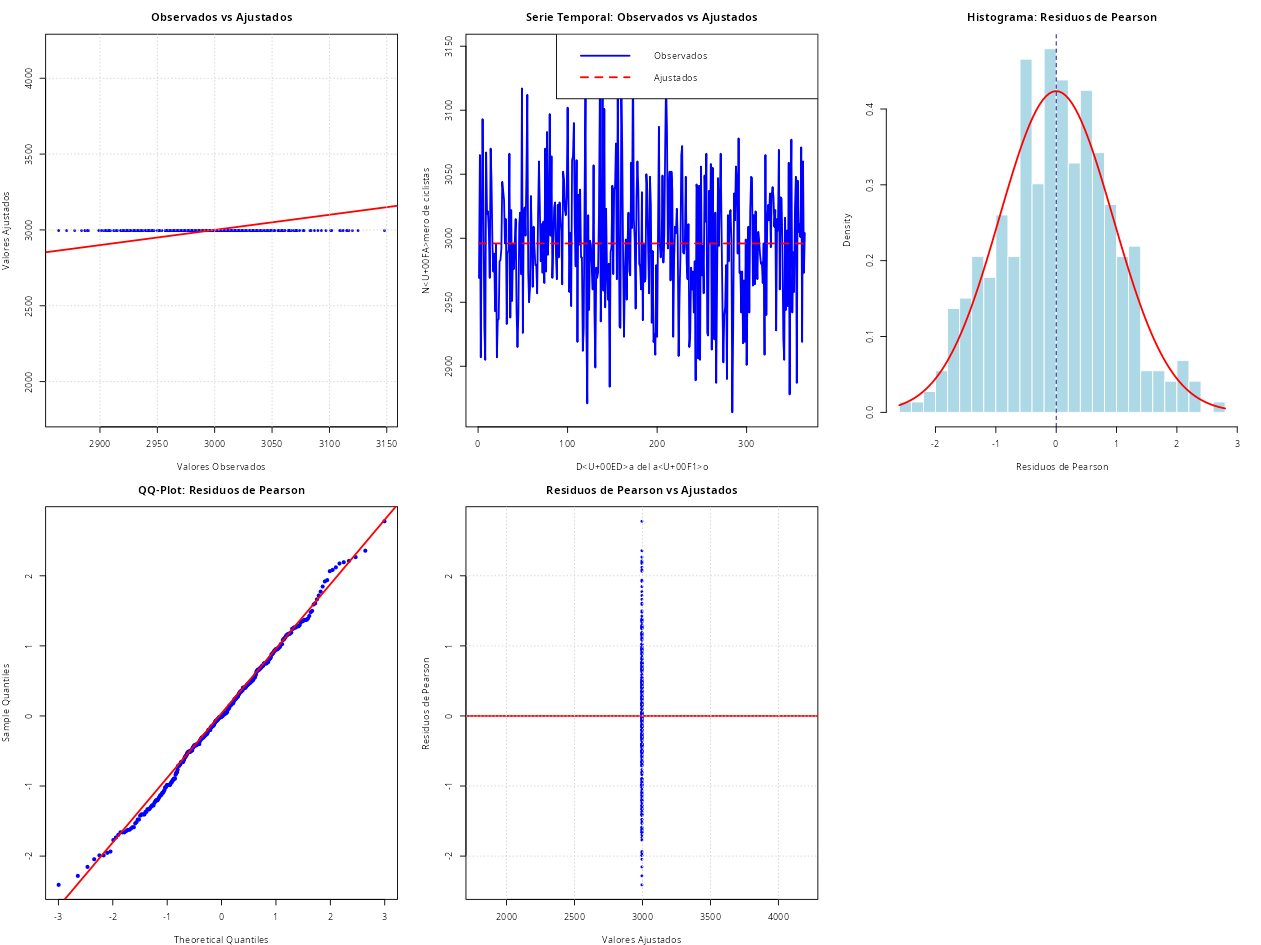

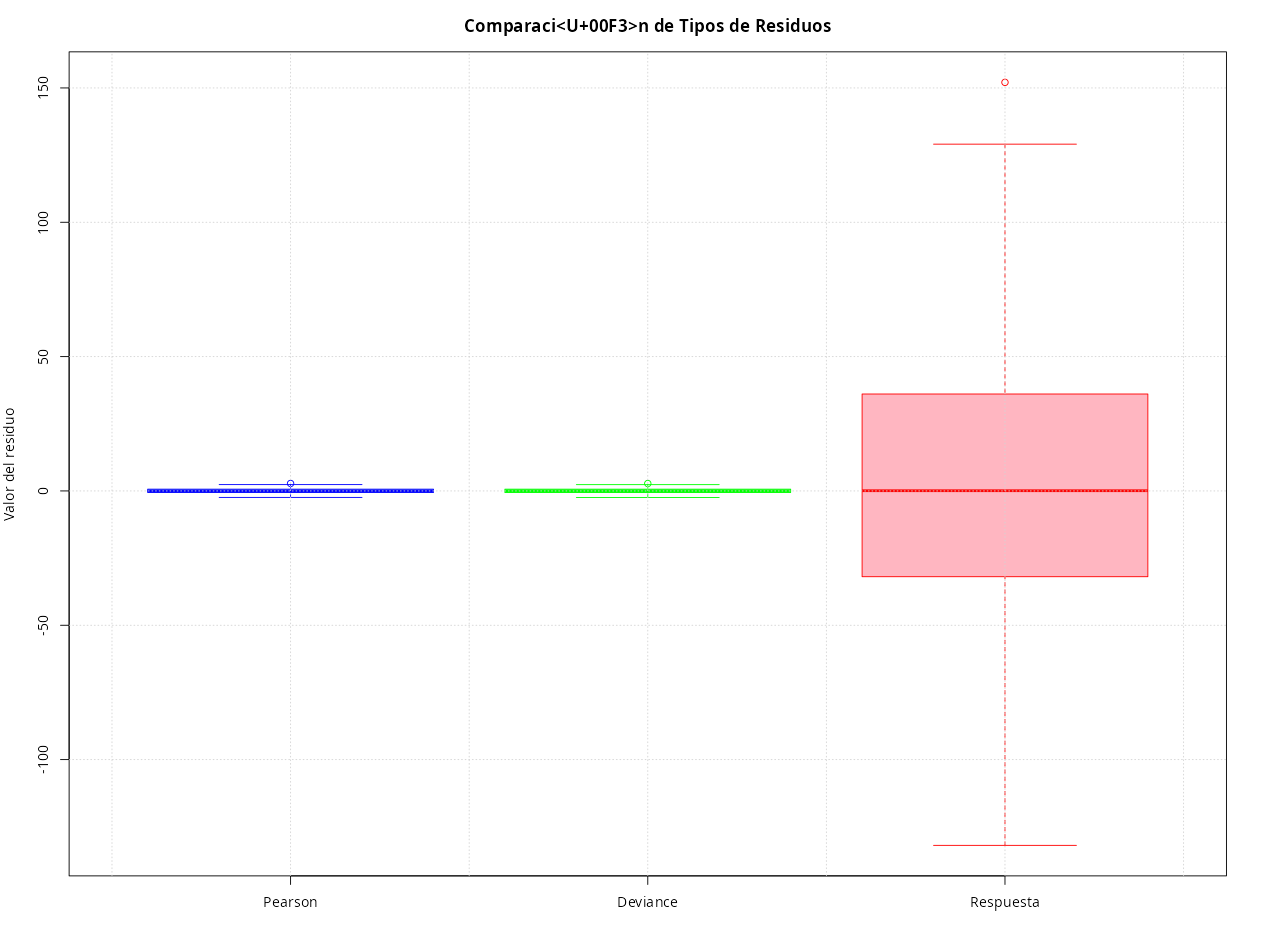

In [8]:

# ============================================================================
# 6. GRÁFICOS
# ============================================================================

# Configurar layout para gráficos
par(mfrow = c(2, 3), mar = c(4, 4, 3, 2))

# Gráfico 1: Valores observados vs ajustados
plot(datos_observados, valores_ajustados,
     main = "Observados vs Ajustados",
     xlab = "Valores Observados",
     ylab = "Valores Ajustados",
     pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 2)
grid()

# Gráfico 2: Serie temporal de observados y ajustados
plot(datos_df$dia, datos_observados, type = "l", col = "blue", lwd = 2,
     main = "Serie Temporal: Observados vs Ajustados",
     xlab = "Día del año", ylab = "Número de ciclistas")
lines(datos_df$dia, valores_ajustados, col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Observados", "Ajustados"),
       col = c("blue", "red"), lty = c(1, 2), lwd = 2)

# Gráfico 3: Histograma de residuos de Pearson
hist(residuos_pearson, breaks = 30, col = "lightblue", border = "white",
     main = "Histograma: Residuos de Pearson",
     xlab = "Residuos de Pearson", freq = FALSE)
curve(dnorm(x, mean = mean(residuos_pearson), sd = sd(residuos_pearson)),
      add = TRUE, col = "red", lwd = 2)
abline(v = 0, col = "darkblue", lty = 2)

# Gráfico 4: QQ-Plot de residuos de Pearson
qqnorm(residuos_pearson, main = "QQ-Plot: Residuos de Pearson",
       pch = 16, col = "blue")
qqline(residuos_pearson, col = "red", lwd = 2)

# Gráfico 5: Residuos de Pearson vs Valores Ajustados
plot(valores_ajustados, residuos_pearson,
     main = "Residuos de Pearson vs Ajustados",
     xlab = "Valores Ajustados", ylab = "Residuos de Pearson",
     pch = 16, col = "blue", cex = 0.7)
abline(h = 0, col = "red", lwd = 2)
grid()

# Gráfico 6: Comparación de tipos de residuos
par(mfrow = c(1, 1))
boxplot(residuos_pearson, residuos_deviance, residuos_respuesta,
        names = c("Pearson", "Deviance", "Respuesta"),
        main = "Comparación de Tipos de Residuos",
        ylab = "Valor del residuo",
        col = c("lightblue", "lightgreen", "lightpink"),
        border = c("blue", "green", "red"))
grid()


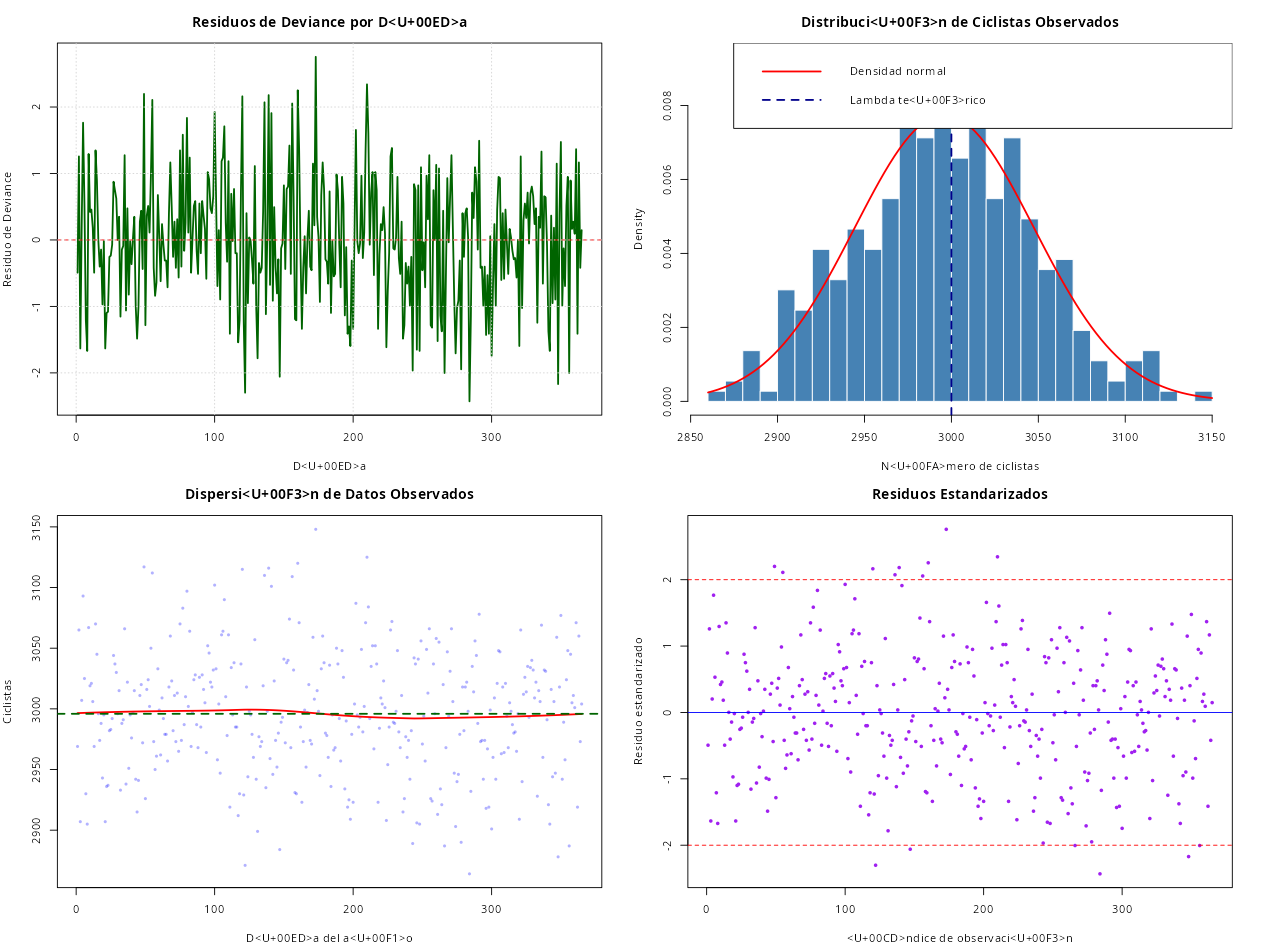

In [9]:

# ============================================================================
# 7. GRÁFICOS ADICIONALES DE DIAGNÓSTICO
# ============================================================================

par(mfrow = c(2, 2))

# Gráfico de residuos de deviance
plot(residuos_deviance, type = "l", col = "darkgreen", lwd = 2,
     main = "Residuos de Deviance por Día",
     xlab = "Día", ylab = "Residuo de Deviance")
abline(h = 0, col = "red", lty = 2)
grid()

# Histograma de datos observados
hist(datos_observados, breaks = 40, col = "steelblue", border = "white",
     main = "Distribución de Ciclistas Observados",
     xlab = "Número de ciclistas", freq = FALSE)
curve(dnorm(x, mean = mean(datos_observados), sd = sd(datos_observados)),
      add = TRUE, col = "red", lwd = 2)
abline(v = lambda, col = "darkblue", lty = 2, lwd = 2)
legend("topright", legend = c("Densidad normal", "Lambda teórico"),
       col = c("red", "darkblue"), lty = c(1, 2), lwd = 2)

# Gráfico de dispersión con línea de tendencia
plot(1:n_dias, datos_observados, pch = 16, cex = 0.6, col = rgb(0, 0, 1, 0.3),
     main = "Dispersión de Datos Observados",
     xlab = "Día del año", ylab = "Ciclistas")
lines(lowess(1:n_dias, datos_observados), col = "red", lwd = 2)
abline(h = lambda_estimado, col = "darkgreen", lty = 2, lwd = 2)

# Residuos estandarizados
residuos_estandarizados <- rstandard(modelo_poisson)
plot(residuos_estandarizados, pch = 16, col = "purple", cex = 0.7,
     main = "Residuos Estandarizados",
     xlab = "Índice de observación", ylab = "Residuo estandarizado")
abline(h = c(-2, 0, 2), col = c("red", "blue", "red"), lty = c(2, 1, 2))


In [10]:

# ============================================================================
# 8. PRUEBAS DE BONDAD DE AJUSTE
# ============================================================================

cat("\n================================================================\n")
cat("PRUEBAS DE BONDAD DE AJUSTE\n")
cat("================================================================\n")

# Desvianza del modelo
devianza <- deviance(modelo_poisson)
gl_residuales <- df.residual(modelo_poisson)

cat(sprintf("Desvianza del modelo: %.4f\n", devianza))
cat(sprintf("Grados de libertad residuales: %d\n", gl_residuales))
cat(sprintf("Razón Desvianza/GL: %.4f\n", devianza/gl_residuales))

# Prueba de bondad de ajuste
p_valor_ajuste <- 1 - pchisq(devianza, gl_residuales)
cat(sprintf("P-valor (prueba chi-cuadrado): %.4f\n", p_valor_ajuste))

if(p_valor_ajuste > 0.05) {
  cat("\n✓ El modelo Poisson ajusta adecuadamente los datos (p > 0.05)\n")
} else {
  cat("\n✗ Posible falta de ajuste del modelo (p ≤ 0.05)\n")
}

# Cálculo de AIC y BIC
cat(sprintf("\nAIC: %.4f\n", AIC(modelo_poisson)))
cat(sprintf("BIC: %.4f\n", BIC(modelo_poisson)))



PRUEBAS DE BONDAD DE AJUSTE
Desvianza del modelo: 322.8383
Grados de libertad residuales: 364
Raz<U+00F3>n Desvianza/GL: 0.8869
P-valor (prueba chi-cuadrado): 0.9409

<U+2713> El modelo Poisson ajusta adecuadamente los datos (p > 0.05)

AIC: 3917.4577
BIC: 3921.3576


In [11]:

# ============================================================================
# 9. ANÁLISIS DE RESIDUOS CUANTÍLICOS
# ============================================================================

cat("\n================================================================\n")
cat("ANÁLISIS DE RESIDUOS CUANTÍLICOS\n")
cat("================================================================\n")

cuantiles_teoricos <- qnorm(ppoints(length(residuos_pearson)))
cuantiles_observados <- sort(residuos_pearson)

# Correlación entre cuantiles teóricos y observados
correlacion_qq <- cor(cuantiles_teoricos, cuantiles_observados)
cat(sprintf("Correlación QQ-Plot: %.4f\n", correlacion_qq))

if(correlacion_qq > 0.95) {
  cat("✓ Los residuos siguen aproximadamente una distribución normal\n")
} else {
  cat("⚠ Desviaciones de la normalidad en los residuos\n")
}



AN<U+00C1>LISIS DE RESIDUOS CUANT<U+00CD>LICOS
Correlaci<U+00F3>n QQ-Plot: 0.9985
<U+2713> Los residuos siguen aproximadamente una distribuci<U+00F3>n normal


In [12]:

# ============================================================================
# 10. RESUMEN FINAL
# ============================================================================

cat("\n================================================================\n")
cat("RESUMEN FINAL DEL ANÁLISIS\n")
cat("================================================================\n")
cat(sprintf("Lambda teórico: %d ciclistas/día\n", lambda))
cat(sprintf("Lambda estimado: %.2f ciclistas/día\n", lambda_estimado))
cat(sprintf("Error relativo: %.2f%%\n", 
            abs(lambda_estimado - lambda)/lambda * 100))
cat(sprintf("P(X = 3000) = %.6f\n", prob_3000))
cat(sprintf("P(X = 3500) = %.10f (evento muy raro)\n", prob_3500))
cat(sprintf("Desviación estándar teórica: %.2f\n", sqrt(lambda)))
cat(sprintf("Coeficiente de variación: %.2f%%\n", 
            sqrt(lambda)/lambda * 100))

cat("\n================================================================\n")
cat("FIN DEL ANÁLISIS\n")
cat("================================================================\n")

# Guardar gráficos en archivo (opcional)
# pdf("analisis_ciclistas_montreal.pdf", width = 12, height = 8)
# [Los gráficos se generarían aquí nuevamente]
# dev.off()


RESUMEN FINAL DEL AN<U+00C1>LISIS
Lambda te<U+00F3>rico: 3000 ciclistas/d<U+00ED>a
Lambda estimado: 2995.92 ciclistas/d<U+00ED>a
Error relativo: 0.14%
P(X = 3000) = 0.007283
P(X = 3500) = 0.0000000000 (evento muy raro)
Desviaci<U+00F3>n est<U+00E1>ndar te<U+00F3>rica: 54.77
Coeficiente de variaci<U+00F3>n: 1.83%

FIN DEL AN<U+00C1>LISIS
